In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

In [2]:
color = cv2.imread('Data/1.jpg')
color = cv2.cvtColor(color,cv2.COLOR_BGR2RGB)

In [3]:
gray = cv2.imread ('DATA/1.jpg',0)

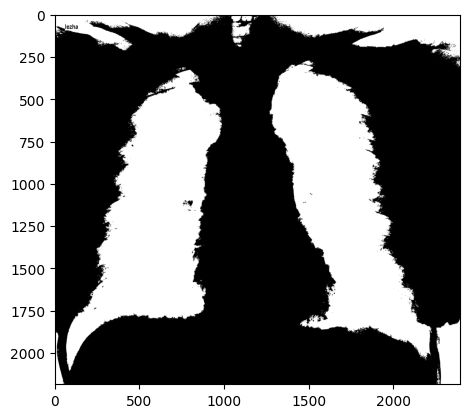

In [4]:
ret, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY_INV)
plt.imshow(thresh, cmap='gray');

In [5]:
kernel = np.ones((5,5),np.uint8)

cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,kernel)
cleaned = cv2.morphologyEx(cleaned,cv2.MORPH_CLOSE,kernel)

## Task 1

Total Boxes Drawn 58


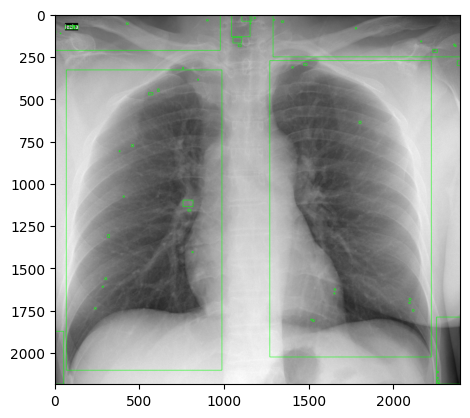

In [6]:
copy1 = color.copy()

contours, hierachy = cv2.findContours(cleaned, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)


for cnt in contours:
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(copy1,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(copy1,cmap='gray')
print(f"Total Boxes Drawn {len(contours)}")

## Task 2

Contours remaining: 7


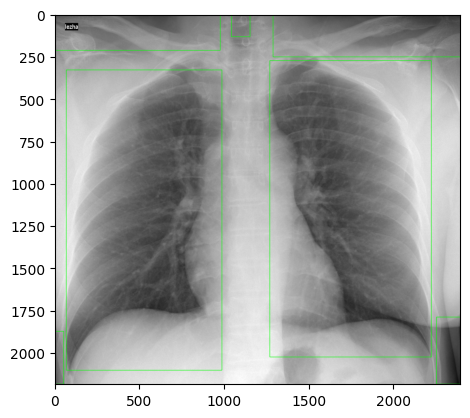

In [7]:
copy2 = color.copy()

contours, hierachy = cv2.findContours(cleaned,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
above_5000 = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 5000:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(copy2,(x,y),(x+w,y+h),(0,255,0),2)
        above_5000 += 1

plt.imshow(copy2, cmap='gray')
print(f"Contours remaining: {above_5000}")

## Task 3

Box Area = 2705
Contour Area = 756903.5
Width = 954
Height = 1751


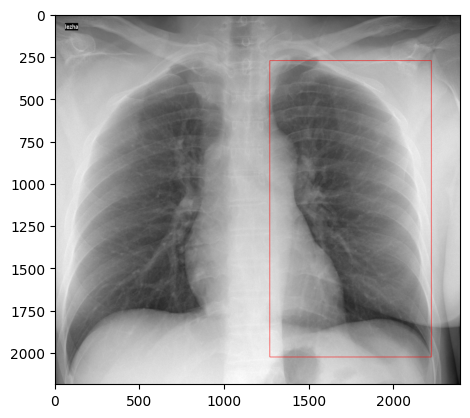

In [8]:
copy3 = color.copy()

contours, hierachy = cv2.findContours(cleaned,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key= cv2.contourArea, reverse=True)
largest = contours_sorted[0]


x,y,w,h = cv2.boundingRect(largest)
cv2.rectangle(copy3,(x,y),(x+w,y+h),(255,0,0),2)
box_area = w+h
area = cv2.contourArea(largest)

plt.imshow(copy3,cmap='gray')
print(f"Box Area = {box_area}")
print(f"Contour Area = {area}")
print(f"Width = {w}")
print(f"Height = {h}")

## Task 4

Left contour area : 756903.5
Right contour area : 750350.0
Left contour area is larger


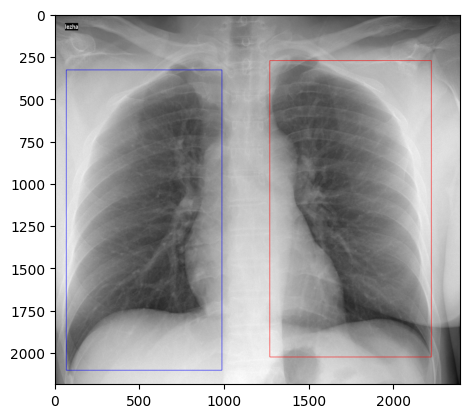

In [20]:
copy4 = color.copy()

contours, hierachy = cv2.findContours(cleaned,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)

left_cnt = contours_sorted[0]
right_cnt = contours_sorted[1]

x,y,w,h = cv2.boundingRect(left_cnt)
cv2.rectangle(copy4,(x,y),(x+w,y+h),(255,0,0),2)
left_area = cv2.contourArea(left_cnt)

x,y,w,h = cv2.boundingRect(right_cnt)
cv2.rectangle(copy4,(x,y),(x+w,y+h),(0,0,255),2)
right_area = cv2.contourArea(right_cnt)

plt.imshow(copy4,cmap='gray');

print(f"Left contour area : {left_area}")
print(f"Right contour area : {right_area}")

if left_area > right_area:
    print("Left contour area is larger")
else:
    print("Right contour area is larger")

## Task 5

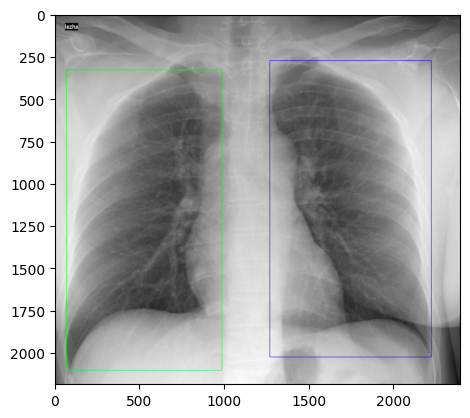

In [14]:
copy5 = color.copy()

contours, hierachy = cv2.findContours(cleaned,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
largest_two = contours_sorted[:2]

colors = [(0,0,255),(0,255,0)]

for i,cnt in enumerate(largest_two):
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(copy5,(x,y),(x+w,y+h),colors[i],2)

plt.imshow(copy5,cmap='gray')
